# Anomaly Classifier Baseline Notebook

This notebook builds the final binary decision layer for the wafer anomaly-detection task.

Important framing for this project:
- the main model is not a supervised defect-type classifier
- the model learns normal wafer structure from normal wafers only
- at inference time it produces an anomaly score
- the "classifier" is the rule that converts that score into `normal` or `anomalous`

So for this project, the classifier is usually a threshold on anomaly score, not a multi-class network trained on all defect labels.

This notebook uses the existing autoencoder baseline and the current best scoring rule, `topk_abs_mean`, to produce binary anomaly decisions.

## What a classifier means in anomaly detection

In a standard supervised classification problem:
- input -> model -> class label
- example labels might be `Center`, `Edge-Ring`, `Scratch`, `none`

In this anomaly-detection problem:
- input -> model -> anomaly score
- anomaly score -> decision rule -> `normal` or `anomalous`

That means the deep model is usually a representation learner or scoring model, while the classifier is the final decision boundary.

For this project, the decision rule should be based on validation-normal behaviour. A common deployment-style rule is:
- compute anomaly scores on validation normal wafers
- choose a high percentile such as the 95th percentile as the threshold
- predict `anomalous` when score > threshold

This is preferable here because:
- defect labels are rare and incomplete
- new defect modes may appear at test time
- training a standard defect-type classifier would overfit known defect classes and miss the open-set nature of the task

So the short answer is: yes, you can have a classifier in anomaly detection, but it is usually a binary decision layer built on top of an anomaly score, not the main learning objective.

In [1]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.evaluation import summarize_threshold_metrics, sweep_threshold_metrics
from wafer_defect.models.autoencoder import ConvAutoencoder
from wafer_defect.scoring import absolute_error_map, topk_spatial_mean

In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "training" / "train_autoencoder.toml"
CHECKPOINT_PATH = REPO_ROOT / "artifacts" / "x64" / "autoencoder_baseline" / "best_model.pt"
TOPK_RATIO = 0.01
THRESHOLD_PERCENTILE = 95.0
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

config = load_toml(CONFIG_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = int(config["data"].get("image_size", 64))
batch_size = int(config["data"].get("batch_size", 64))
num_workers = int(config["data"].get("num_workers", 0))

config

{'run': {'output_dir': 'artifacts/x64/autoencoder_baseline', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 2},
 'training': {'epochs': 50,
  'learning_rate': 0.001,
  'weight_decay': 0.0001,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 5e-05,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'autoencoder', 'latent_dim': 128}}

## Load processed splits

The current dataset design is:
- `train`: normal only
- `val`: normal only
- `test`: mixture of normal and labelled anomalies

That is why validation is used to set the score threshold rather than to train a supervised classifier.

In [3]:
train_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="train", image_size=image_size)
val_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="val", image_size=image_size)
test_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="test", image_size=image_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

split_summary = pd.DataFrame(
    [
        {"split": "train", "samples": len(train_dataset), "anomalies": int(train_dataset.metadata["is_anomaly"].sum())},
        {"split": "val", "samples": len(val_dataset), "anomalies": int(val_dataset.metadata["is_anomaly"].sum())},
        {"split": "test", "samples": len(test_dataset), "anomalies": int(test_dataset.metadata["is_anomaly"].sum())},
    ]
)
split_summary

,split,samples,anomalies
0,train,40000,0
1,val,5000,0
2,test,5250,250


## Load the trained autoencoder

If `best_model.pt` does not exist yet, run the autoencoder training notebook first.

In [4]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model = ConvAutoencoder(
    latent_dim=int(config["model"]["latent_dim"]),
    image_size=image_size,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'best_epoch', 'best_val_loss', 'stale_epochs', 'history'])

In [5]:
@torch.no_grad()
def collect_scores(model, loader, device, topk_ratio=0.01):
    all_scores = []
    all_labels = []
    all_inputs = []
    all_recons = []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        reconstructions = model(inputs)
        error_map = absolute_error_map(inputs, reconstructions)
        scores = topk_spatial_mean(error_map, topk_ratio=topk_ratio)

        all_scores.append(scores.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_inputs.append(inputs.cpu().numpy())
        all_recons.append(reconstructions.cpu().numpy())

    return {
        "scores": np.concatenate(all_scores),
        "labels": np.concatenate(all_labels),
        "inputs": np.concatenate(all_inputs),
        "recons": np.concatenate(all_recons),
    }

val_outputs = collect_scores(model, val_loader, device, topk_ratio=TOPK_RATIO)
test_outputs = collect_scores(model, test_loader, device, topk_ratio=TOPK_RATIO)

len(val_outputs["scores"]), len(test_outputs["scores"])

(5000, 5250)

## Build the anomaly classifier

This notebook uses a threshold classifier:

- if `score <= threshold`: predict normal
- if `score > threshold`: predict anomalous

This is the correct first classifier for your stated problem because it respects the unsupervised training setup.

In [6]:
threshold = float(np.percentile(val_outputs["scores"], THRESHOLD_PERCENTILE))
test_summary = summarize_threshold_metrics(test_outputs["labels"], test_outputs["scores"], threshold)
sweep_df, best_sweep = sweep_threshold_metrics(test_outputs["labels"], test_outputs["scores"])

print(f"Validation-normal threshold ({THRESHOLD_PERCENTILE:.1f}th percentile): {threshold:.6f}")
print(json.dumps(test_summary, indent=2))
print(json.dumps(best_sweep, indent=2))

Validation-normal threshold (95.0th percentile): 0.639834
{
  "threshold": 0.6398341655731201,
  "precision": 0.3810810810810811,
  "recall": 0.564,
  "f1": 0.45483870967741935,
  "auroc": 0.8369039999999999,
  "auprc": 0.5280209066591793,
  "predicted_anomalies": 370,
  "confusion_matrix": [
    [
      4771,
      229
    ],
    [
      109,
      141
    ]
  ]
}
{
  "threshold": 0.6874095797538757,
  "precision": 0.6338797814207651,
  "recall": 0.464,
  "f1": 0.5357967667431609,
  "predicted_anomalies": 182
}


In [7]:
score_df = pd.DataFrame(
    {
        "score": test_outputs["scores"],
        "label": test_outputs["labels"],
        "prediction": (test_outputs["scores"] > threshold).astype(int),
    }
)
score_df["label_name"] = score_df["label"].map({0: "normal", 1: "anomaly"})
score_df["prediction_name"] = score_df["prediction"].map({0: "normal", 1: "anomaly"})
score_df.head()

,score,label,prediction,label_name,prediction_name
0,0.553635,0,0,normal,normal
1,0.587331,0,0,normal,normal
2,0.603066,0,0,normal,normal
3,0.637784,0,0,normal,normal
4,0.473047,0,0,normal,normal


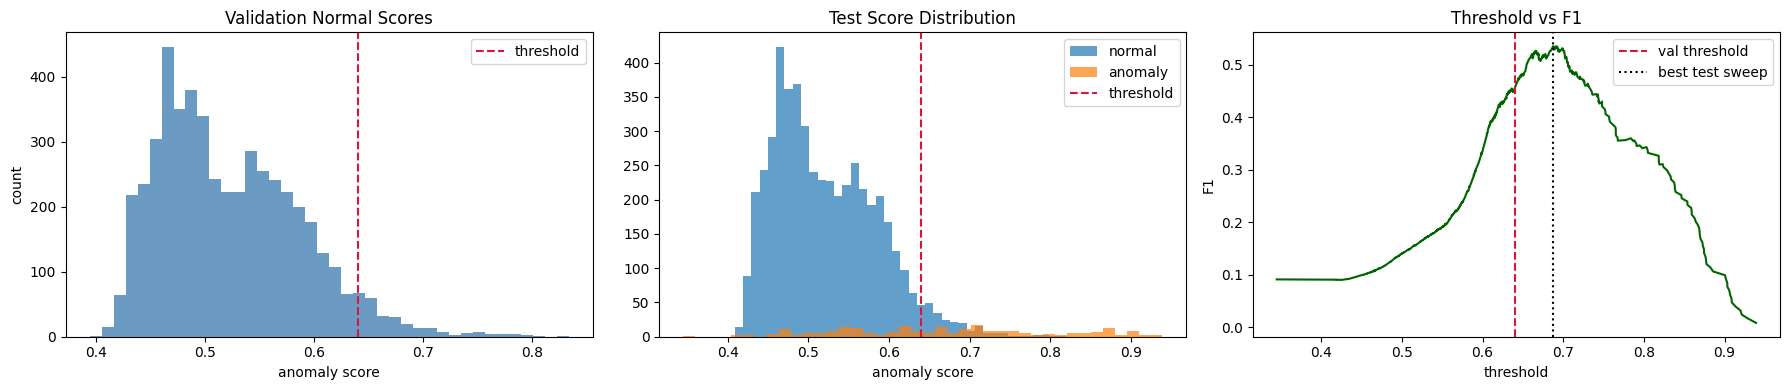

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(val_outputs["scores"], bins=40, alpha=0.8, color="steelblue")
axes[0].axvline(threshold, color="crimson", linestyle="--", label="threshold")
axes[0].set_title("Validation Normal Scores")
axes[0].set_xlabel("anomaly score")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(test_outputs["scores"][test_outputs["labels"] == 0], bins=40, alpha=0.7, label="normal")
axes[1].hist(test_outputs["scores"][test_outputs["labels"] == 1], bins=40, alpha=0.7, label="anomaly")
axes[1].axvline(threshold, color="crimson", linestyle="--", label="threshold")
axes[1].set_title("Test Score Distribution")
axes[1].set_xlabel("anomaly score")
axes[1].legend()

axes[2].plot(sweep_df["threshold"], sweep_df["f1"], color="darkgreen")
axes[2].axvline(threshold, color="crimson", linestyle="--", label="val threshold")
axes[2].axvline(best_sweep["threshold"], color="black", linestyle=":", label="best test sweep")
axes[2].set_title("Threshold vs F1")
axes[2].set_xlabel("threshold")
axes[2].set_ylabel("F1")
axes[2].legend()

plt.tight_layout()

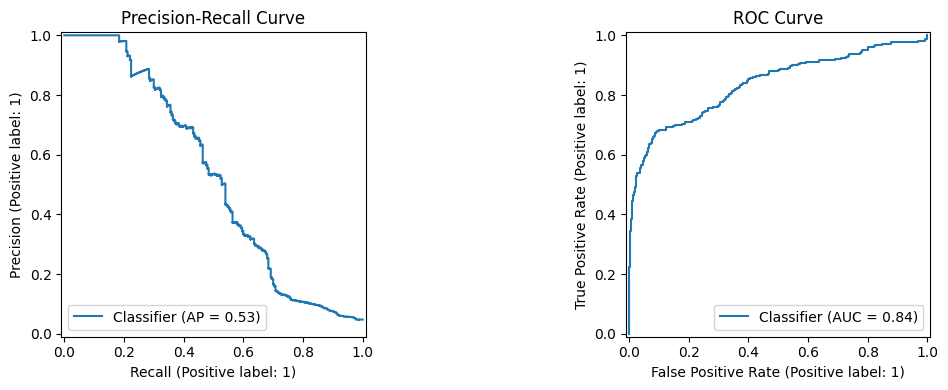

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PrecisionRecallDisplay.from_predictions(test_outputs["labels"], test_outputs["scores"], ax=axes[0])
axes[0].set_title("Precision-Recall Curve")

RocCurveDisplay.from_predictions(test_outputs["labels"], test_outputs["scores"], ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()

## Inspect correct and incorrect decisions

This is useful because the current report suggests the system is stronger on broad defects such as `Edge-Ring` and weaker on subtle local defects such as `Loc` and `Scratch`.

In [10]:
test_metadata = test_dataset.metadata.reset_index(drop=True).copy()
test_metadata["score"] = test_outputs["scores"]
test_metadata["prediction"] = (test_outputs["scores"] > threshold).astype(int)
test_metadata["error_type"] = np.select(
    [
        (test_metadata["is_anomaly"] == 1) & (test_metadata["prediction"] == 1),
        (test_metadata["is_anomaly"] == 1) & (test_metadata["prediction"] == 0),
        (test_metadata["is_anomaly"] == 0) & (test_metadata["prediction"] == 1),
    ],
    ["true_positive", "false_negative", "false_positive"],
    default="true_negative",
)

test_metadata.groupby("error_type")["score"].agg(["count", "mean", "median"]).sort_values("count", ascending=False)

,count,mean,median
error_type,,,
true_negative,4771,0.513821,0.503808
false_positive,229,0.677470,0.666540
true_positive,141,0.767463,0.748014
false_negative,109,0.547865,0.551865


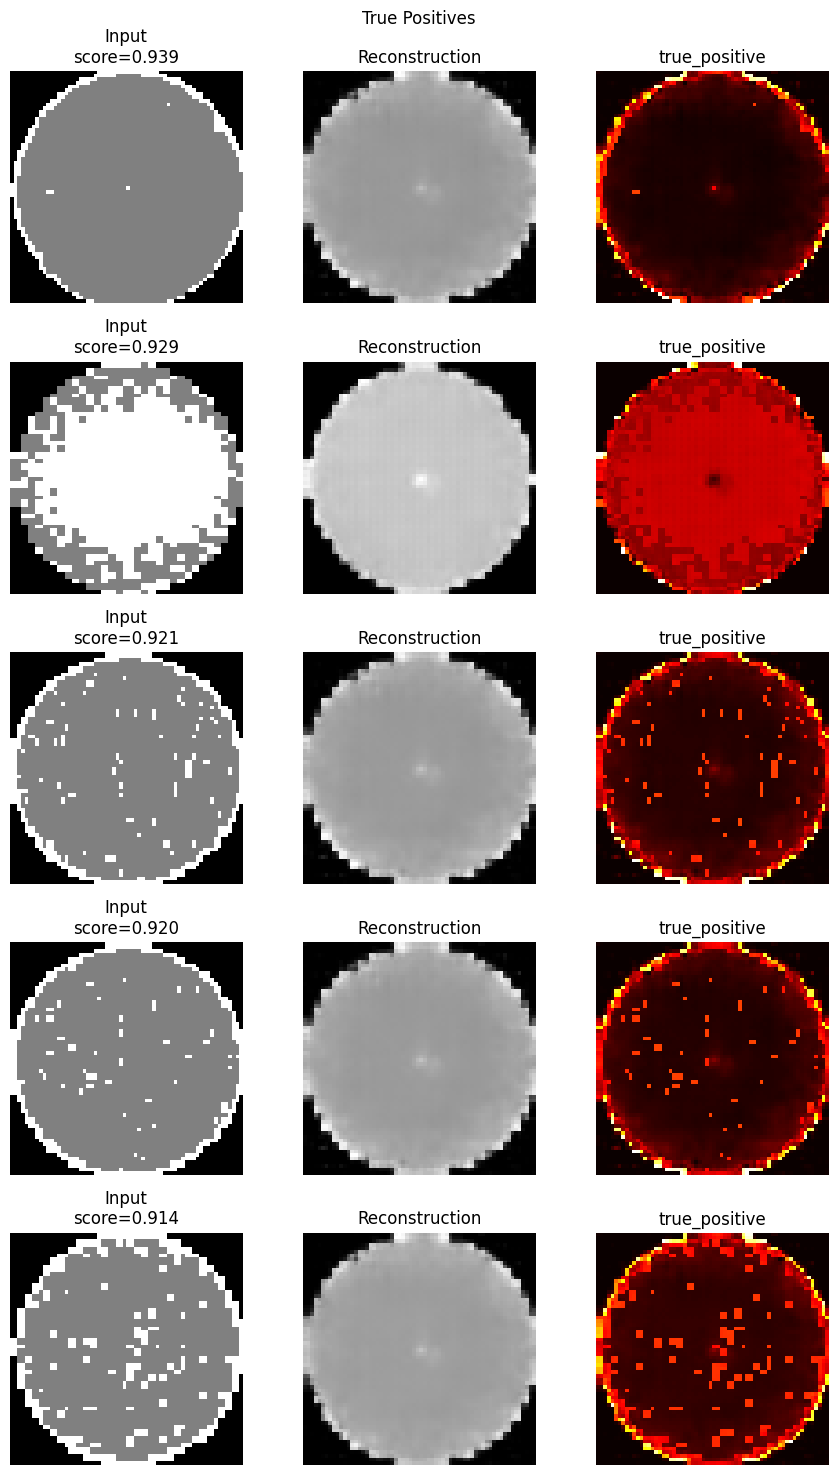

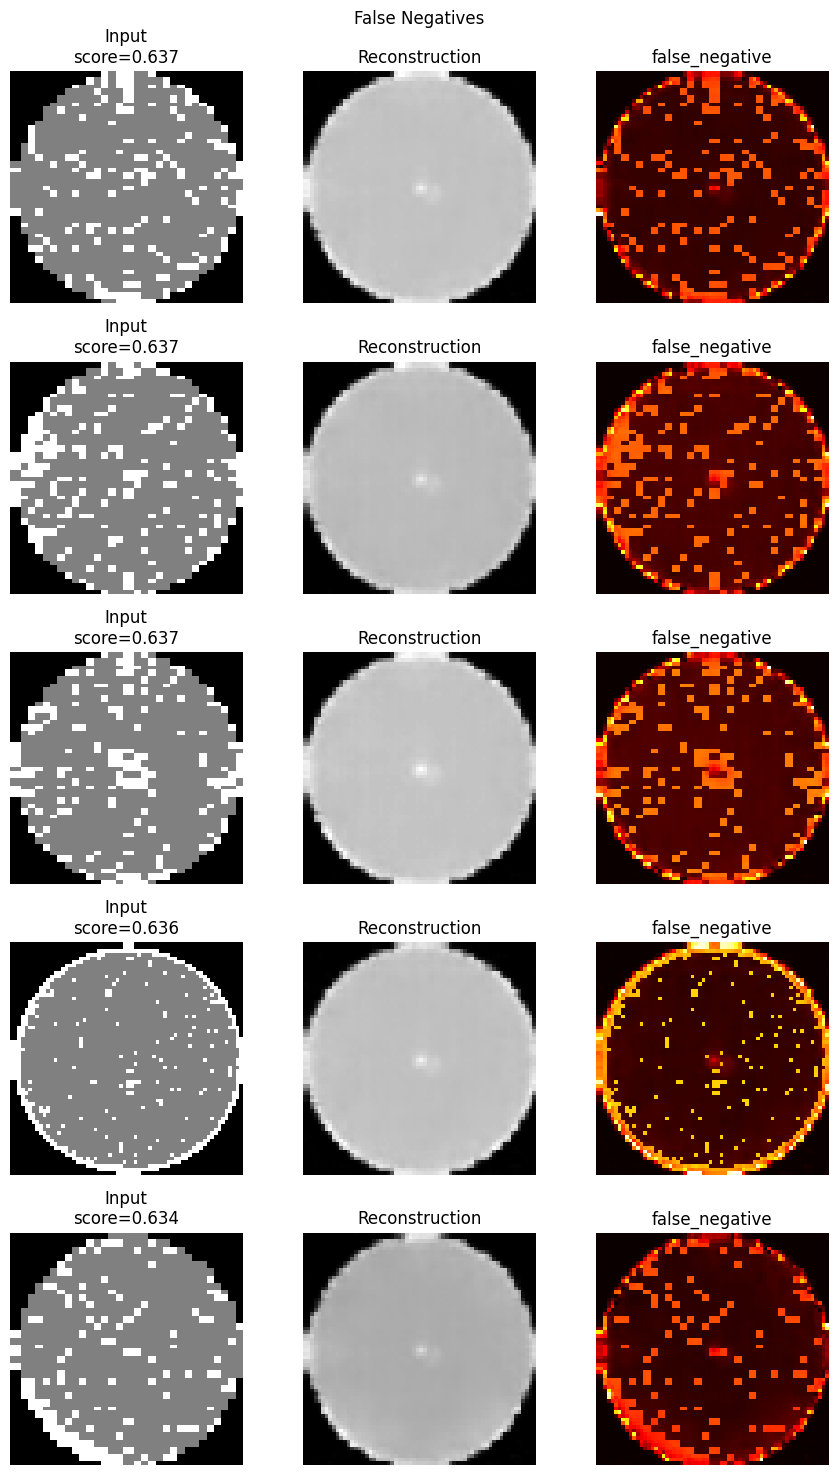

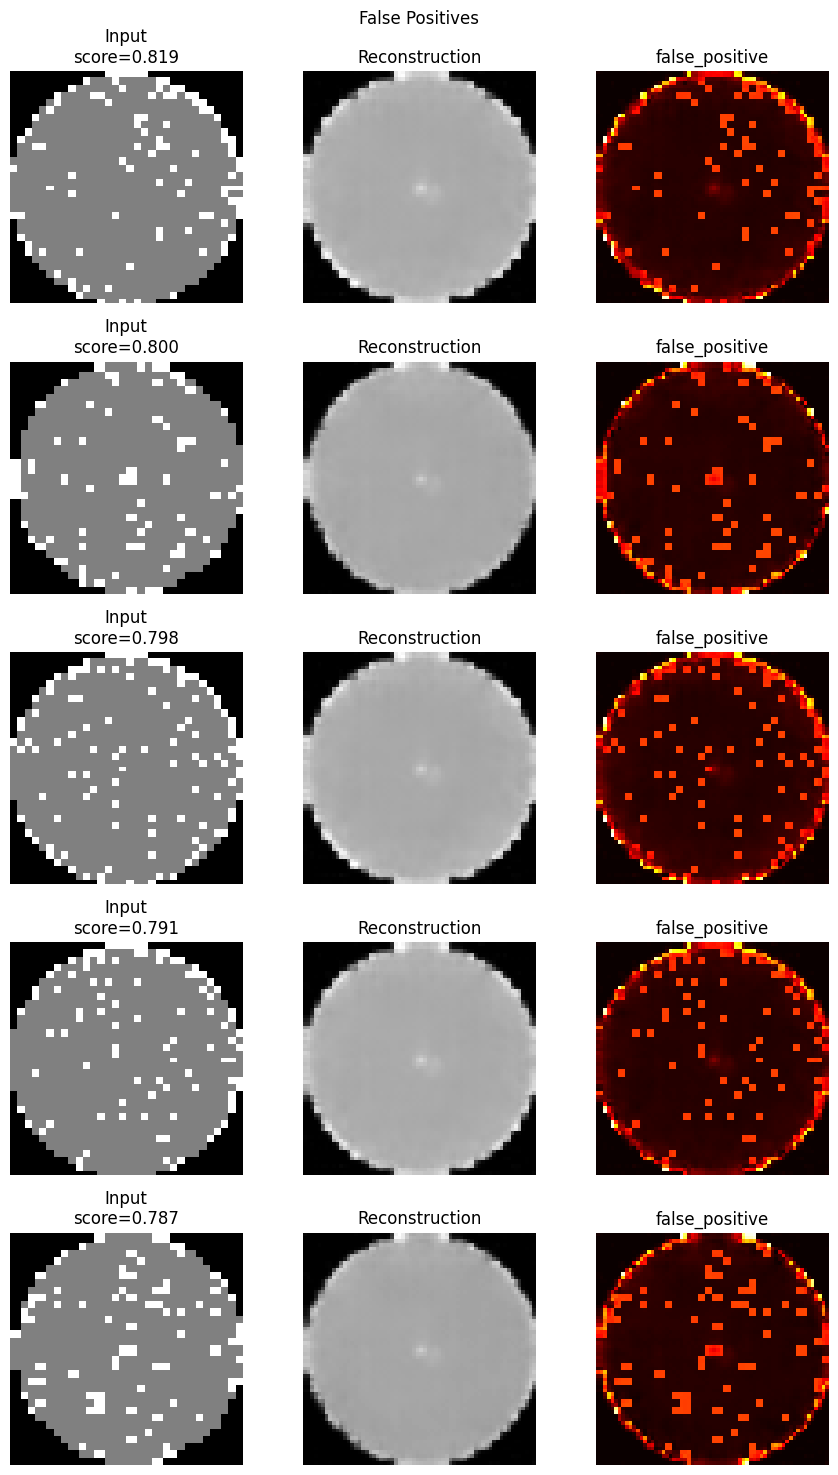

In [11]:
def show_examples(frame, title, count=5):
    subset = frame.head(count).copy()
    if subset.empty:
        print(f"No rows available for {title}")
        return

    fig, axes = plt.subplots(len(subset), 3, figsize=(9, 3 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_axes, (_, row) in zip(axes, subset.iterrows()):
        idx = int(row.name)
        wafer = test_outputs["inputs"][idx, 0]
        recon = test_outputs["recons"][idx, 0]
        err = np.abs(recon - wafer)

        row_axes[0].imshow(wafer, cmap="gray")
        row_axes[0].set_title(f"Input\nscore={row['score']:.3f}")
        row_axes[1].imshow(recon, cmap="gray")
        row_axes[1].set_title("Reconstruction")
        row_axes[2].imshow(err, cmap="hot")
        row_axes[2].set_title(row["error_type"])

        for ax in row_axes:
            ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()

show_examples(test_metadata.query("error_type == 'true_positive'").sort_values("score", ascending=False), "True Positives")
show_examples(test_metadata.query("error_type == 'false_negative'").sort_values("score", ascending=False), "False Negatives")
show_examples(test_metadata.query("error_type == 'false_positive'").sort_values("score", ascending=False), "False Positives")